In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

In [2]:
lensing_profiles = Table.read('mock_DC2like_data.fits')

In [3]:
def binning(corner): return [[corner[i],corner[i+1]] for i in range(len(corner)-1)]

z_corner = np.array([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])
Z_bin = np.array(binning(z_corner))
rich_corner = np.array([20, 35, 70, 100, 200])
rich_corner = np.array([r for r in rich_corner])
Obs_bin = np.array(binning(rich_corner))
Obs_bin_center = np.mean(Obs_bin, axis=1)
Z_bin_center = np.mean(Z_bin, axis=1)

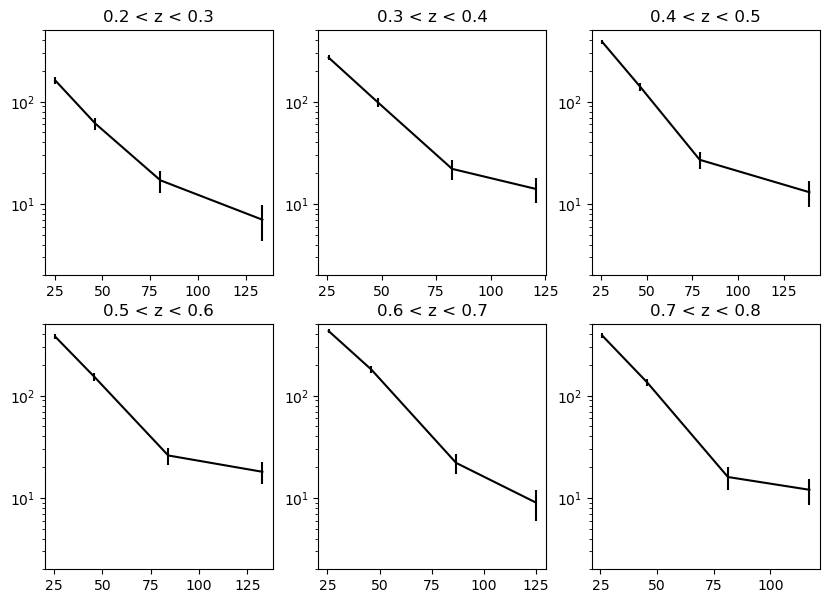

In [4]:
plt.figure(figsize=(10, 7))
for i, z_bin in enumerate(Z_bin):

    plt.subplot(231+i)
    plt.title(f'{z_bin[0]:.1f} < z < {z_bin[1]:.1f}')
    plt.ylim(2,500)
    plt.yscale('log')

    x = []
    y = []
    for j, rich_bin in enumerate(Obs_bin):

        mask = (lensing_profiles['cluster_redshift'] > z_bin[0])*(lensing_profiles['cluster_redshift'] <= z_bin[1])
        mask *= (lensing_profiles['cluster_richness'] > rich_bin[0])*(lensing_profiles['cluster_richness'] <= rich_bin[1])
        x.append(np.mean(lensing_profiles['cluster_richness'][mask]))
        y.append(np.sum(mask))
    plt.errorbar(x, y, np.sqrt(np.array(y)), color= 'k')

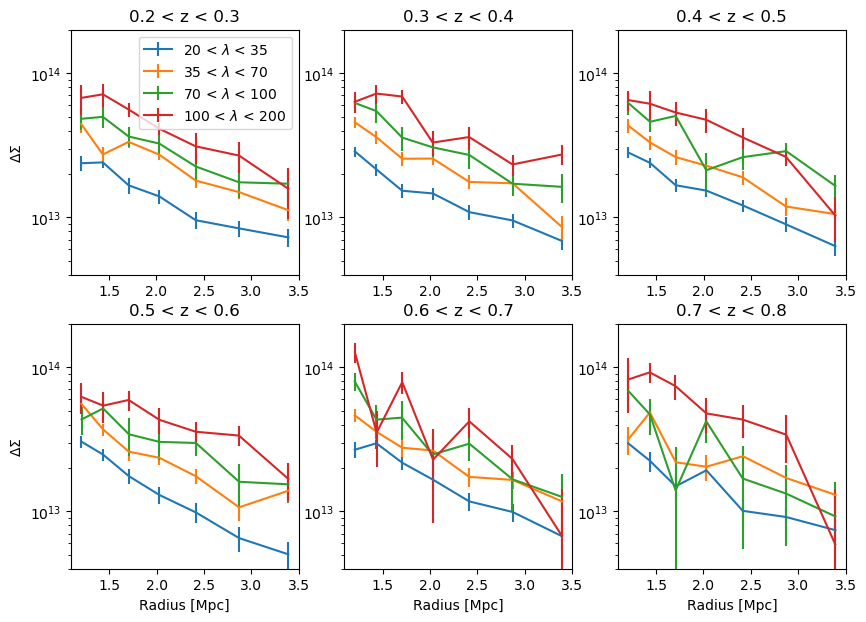

In [5]:
plt.figure(figsize=(10, 7))
for i, z_bin in enumerate(Z_bin):

    plt.subplot(231+i)
    plt.title(f'{z_bin[0]:.1f} < z < {z_bin[1]:.1f}')
    plt.yscale('log')
    plt.ylim(4e12, 2e14)
    if i >= 3:
        plt.xlabel('Radius [Mpc]')
    if i == 0 or i == 3:
        plt.ylabel(r'$\Delta\Sigma$')
    
    for j, rich_bin in enumerate(Obs_bin):

        mask = (lensing_profiles['cluster_redshift'] > z_bin[0])*(lensing_profiles['cluster_redshift'] <= z_bin[1])
        mask *= (lensing_profiles['cluster_richness'] > rich_bin[0])*(lensing_profiles['cluster_richness'] <= rich_bin[1])
        lensing_profiles_bin = lensing_profiles[mask]
        x_mean = np.mean(lensing_profiles_bin['binned_radius_Mpc'],axis=0)
        y_mean = np.average(lensing_profiles_bin['binned_profiles'], weights=lensing_profiles_bin['binned_weights'], axis=0)
        y_err_mean = np.std(lensing_profiles_bin['binned_profiles'], axis=0)/np.sqrt(np.sum(mask))
        plt.errorbar(x_mean, y_mean, y_err_mean, label = f'{rich_bin[0]:.0f} < $\lambda$ < {rich_bin[1]:.0f}')
        if i==0: 
                plt.legend()